In [8]:
import numpy as np
import random
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input 
from tensorflow.keras.optimizers import Adam
from collections import deque
import matplotlib.pyplot as plt
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [9]:
# --- Paramètres du jeu ---
GRID_SIZE = 4 
STATE_SIZE = GRID_SIZE * GRID_SIZE 
ACTION_SIZE = 4  # Haut, Bas, Gauche, Droite 
GAMMA = 0.9  
LEARNING_RATE = 0.001 # Réduit pour DDQN
EPSILON = 1.0  
EPSILON_MIN = 0.01 
EPSILON_DECAY = 0.995 
BATCH_SIZE = 32 
MEMORY_SIZE = 2000 
EPISODES = 500 # Le DDQN converge souvent plus vite
TARGET_UPDATE_FREQ = 10 # Fréquence de mise à jour du réseau cible

MOVES = {0: (-1, 0),
          1: (1, 0), 
          2: (0, -1), 
          3: (0, 1)}

In [10]:
class GridWorld:
    def __init__(self):
        self.grid_size = GRID_SIZE 
        self.reset() 
 
    def reset(self): 
        self.agent_pos = (0, 0) 
        self.goal_pos = (3, 3) 
        self.obstacle_pos = (1, 1) 
        return self.get_state() 
 
    def get_state(self): 
        state = np.zeros((GRID_SIZE, GRID_SIZE)) 
        state[self.agent_pos] = 1 
        return state.flatten() 
 
    def step(self, action): 
        x, y = self.agent_pos 
        dx, dy = MOVES[action] 
        new_x, new_y = x + dx, y + dy 
 
        if 0 <= new_x < GRID_SIZE and 0 <= new_y < GRID_SIZE: 
            self.agent_pos = (new_x, new_y) 
 
        if self.agent_pos == self.goal_pos: 
            return self.get_state(), 10, True  
        elif self.agent_pos == self.obstacle_pos: 
            return self.get_state(), -5, False  
        else: 
            return self.get_state(), -1, False

In [13]:
class DoubleDQNAgent:
    def __init__(self):
        self.state_size = STATE_SIZE
        self.action_size = ACTION_SIZE
        self.memory = deque(maxlen=MEMORY_SIZE)
        self.epsilon = EPSILON
        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_network()

    def _build_model(self):
        model = Sequential([
            Input(shape=(self.state_size,)),
            Dense(24, activation='relu'),
            Dense(24, activation='relu'),
            Dense(self.action_size, activation='linear')
        ])
        model.compile(loss="mse", optimizer=Adam(learning_rate=LEARNING_RATE))
        return model

    def update_target_network(self):
        self.target_model.set_weights(self.model.get_weights())

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        # VERSION RAPIDE : Appel direct au lieu de .predict()
        state_input = np.array([state], dtype=np.float32)
        q_values = self.model(state_input, training=False)
        return np.argmax(q_values[0])

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def replay(self):
        if len(self.memory) < BATCH_SIZE:
            return
        
        # Tirage du batch
        batch = random.sample(self.memory, BATCH_SIZE)
        states = np.array([t[0] for t in batch], dtype=np.float32)
        actions = [t[1] for t in batch]
        rewards = [t[2] for t in batch]
        next_states = np.array([t[3] for t in batch], dtype=np.float32)
        dones = [t[4] for t in batch]

        # Prédictions vectorisées (Beaucoup plus rapide !)
        current_q_values = self.model(states, training=False).numpy()
        next_q_online = self.model(next_states, training=False).numpy()
        next_q_target = self.target_model(next_states, training=False).numpy()

        for i in range(BATCH_SIZE):
            if dones[i]:
                current_q_values[i][actions[i]] = rewards[i]
            else:
                # Logique Double DQN
                best_action = np.argmax(next_q_online[i])
                current_q_values[i][actions[i]] = rewards[i] + GAMMA * next_q_target[i][best_action]

        # Entraînement sur tout le batch d'un coup
        self.model.fit(states, current_q_values, epochs=1, verbose=0)

        if self.epsilon > EPSILON_MIN:
            self.epsilon *= EPSILON_DECAY

In [19]:
import matplotlib.pyplot as plt

# --- Initialisation ---
env = GridWorld()
agent = DoubleDQNAgent()
scores = []
epsilon_history = []  # Pour le graphique d'exploration


print("DÉBUT DE L'ENTRAÎNEMENT - DOUBLE DQN")


for episode in range(EPISODES):
    state = env.reset()
    total_reward = 0
    
    for step in range(50):
        action = agent.act(state)
        next_state, reward, done = env.step(action)
        agent.remember(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        if done:
            break
    
    # Entraînement
    agent.replay()
    
    # Stockage des données pour visualisation
    scores.append(total_reward)
    epsilon_history.append(agent.epsilon)
    
    # Mise à jour périodique du réseau CIBLE (Essentiel pour DDQN)
    if (episode + 1) % TARGET_UPDATE_FREQ == 0:
        agent.update_target_network()
    
    # Affichage console
    if (episode + 1) % 50 == 0:
        avg_score = np.mean(scores[-50:])
        print(f"Épisode {episode+1:4d}/{EPISODES} | Score: {total_reward:3d} | Moyenne: {avg_score:5.1f} | Epsilon: {agent.epsilon:.2f}")

# --- Sauvegarde ---
agent.model.save("double_dqn_model.keras")
print("\n[INFO] Modèle sauvegardé sous 'double_dqn_model.keras'")


DÉBUT DE L'ENTRAÎNEMENT - DOUBLE DQN
Épisode   50/500 | Score: -43 | Moyenne: -22.9 | Epsilon: 0.78
Épisode  100/500 | Score:   0 | Moyenne: -12.3 | Epsilon: 0.61
Épisode  150/500 | Score:   5 | Moyenne:  -4.8 | Epsilon: 0.47
Épisode  200/500 | Score:  -3 | Moyenne:  -0.4 | Epsilon: 0.37
Épisode  250/500 | Score:  -4 | Moyenne:   1.7 | Epsilon: 0.29
Épisode  300/500 | Score:   5 | Moyenne:   2.5 | Epsilon: 0.22
Épisode  350/500 | Score:   5 | Moyenne:   3.7 | Epsilon: 0.17
Épisode  400/500 | Score:   5 | Moyenne:   4.2 | Epsilon: 0.13
Épisode  450/500 | Score:   4 | Moyenne:   3.9 | Epsilon: 0.10
Épisode  500/500 | Score:   5 | Moyenne:   3.8 | Epsilon: 0.08

[INFO] Modèle sauvegardé sous 'double_dqn_model.keras'


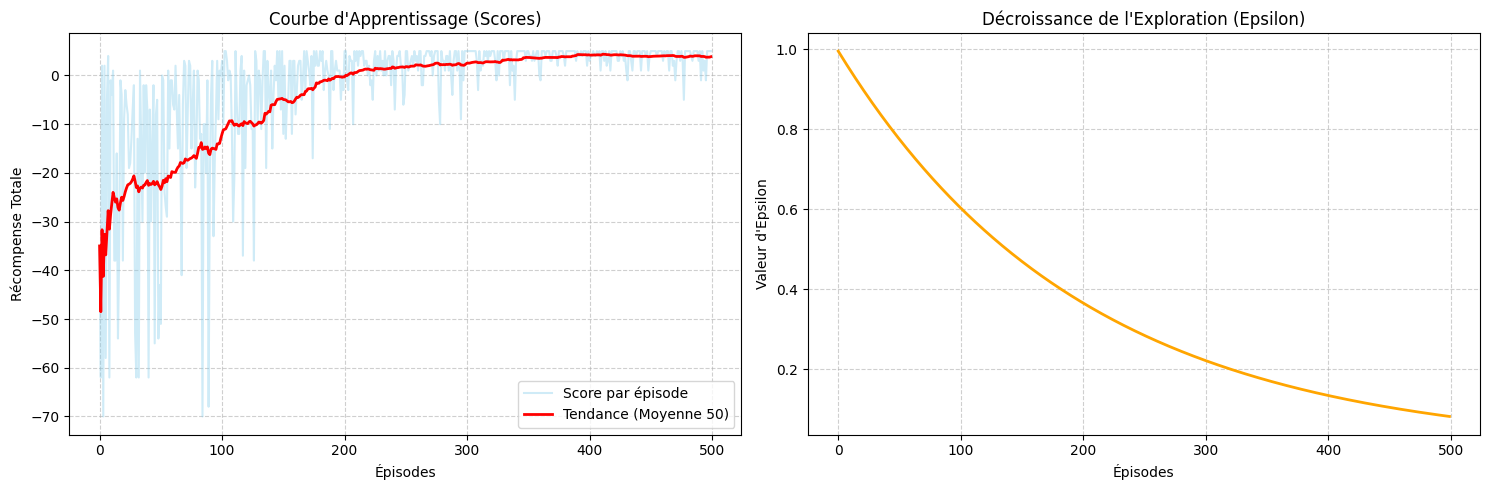

In [20]:
import matplotlib.pyplot as plt

def plot_learning_curves(scores, epsilons):
    plt.figure(figsize=(15, 5))

    # --- Graphique 1 : Évolution du Score ---
    plt.subplot(1, 2, 1)
    plt.plot(scores, label='Score par épisode', color='skyblue', alpha=0.4)
    # Moyenne mobile pour lisser la courbe (fenêtre de 50)
    if len(scores) >= 50:
        moving_avg = [np.mean(scores[max(0, i-50):i+1]) for i in range(len(scores))]
        plt.plot(moving_avg, label='Tendance (Moyenne 50)', color='red', linewidth=2)
    
    plt.title('Courbe d\'Apprentissage (Scores)')
    plt.xlabel('Épisodes')
    plt.ylabel('Récompense Totale')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    # --- Graphique 2 : Décroissance de l'Exploration ---
    plt.subplot(1, 2, 2)
    plt.plot(epsilons, color='orange', linewidth=2)
    plt.title('Décroissance de l\'Exploration (Epsilon)')
    plt.xlabel('Épisodes')
    plt.ylabel('Valeur d\'Epsilon')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Appel de la fonction
plot_learning_curves(scores, epsilon_history)

In [22]:
# --- PHASE DE TEST (Vérification visuelle) ---
state = env.reset()
done = False
steps = 0
print("\n TEST DU CHEMIN OPTIMAL ")
while not done and steps < 15:
    # L'agent choisit la meilleure action (Exploitation pure)
    state_input = np.array([state], dtype=np.float32)
    q_values = agent.model(state_input, training=False)
    action = np.argmax(q_values[0])
    
    state, reward, done = env.step(action)
    steps += 1
    
    # Affichage de la position (x, y)
    pos = np.where(state.reshape(GRID_SIZE, GRID_SIZE) == 1)
    print(f"Étape {steps} : Position de l'agent -> ({pos[0][0]}, {pos[1][0]})")

if reward == 10:
    print("RÉSULTAT : Objectif atteint avec succès ! ")
else:
    print("RÉSULTAT : Échec ou chemin trop long. ")



 TEST DU CHEMIN OPTIMAL 
Étape 1 : Position de l'agent -> (1, 0)
Étape 2 : Position de l'agent -> (2, 0)
Étape 3 : Position de l'agent -> (2, 1)
Étape 4 : Position de l'agent -> (2, 2)
Étape 5 : Position de l'agent -> (3, 2)
Étape 6 : Position de l'agent -> (3, 3)
RÉSULTAT : Objectif atteint avec succès ! 
